# 🔮 Time-Series Forecasting with Prophet

**Prophet** models time series as **trend + seasonalities + holidays/regressors**, with automatic **changepoints** for level shifts. It’s great for business/energy data with clear **daily/weekly/yearly** cycles and simple to extend with holidays or weather.
**Strengths:** quick setup, interpretable components, built-in cross-validation and uncertainty intervals.
**Watch-outs:** may underfit highly irregular patterns; needs careful frequency/TZ handling; multiplicative seasonality often better for energy.
**Key knobs:** `changepoint_prior_scale` (trend flexibility), `seasonality_mode` (additive vs multiplicative), `seasonality_prior_scale`, `holidays_prior_scale`, `growth` (linear/logistic).

This tutorial turns **Prophet** into a clean, reproducible baseline for energy forecasting.  
Prophet models **trend + multiple seasonalities + holidays/regressors**, with robust handling of **changepoints**.

**What you'll learn**
- 📥 Prepare data in Prophet’s format (`ds`, `y`)  
- 🧭 Add **daily/weekly/yearly** seasonality and **holidays**  
- 📈 Control **trend** & **changepoints** (sudden level shifts)  
- ➕ Add **extra regressors** (temperature, events)  
- ✂️ Time-aware train/validation split & cross‑validation  
- 📏 Metrics & diagnostic plots  
- 🎛️ Key knobs: growth, seasonality mode, priors

> Mental model: Prophet = `y(t) = trend(t) + Σ seasonality_k(t) + holiday(t) + regressors(t) + noise`.

## 🛠️ Setup & Imports

We use **pandas/numpy** for data; **matplotlib** for plots; and **prophet** (or **fbprophet** in older versions) for the model.  
Check your install: `pip install prophet` (CPU only) or `conda install -c conda-forge prophet`.

## 🔁 Cross‑Validation (Prophet Diagnostics)

Use built‑in utilities:
```python
from prophet.diagnostics import cross_validation, performance_metrics
df_cv = cross_validation(m, initial="365 days", period="30 days", horizon="30 days")
df_p = performance_metrics(df_cv)
```
This performs rolling‑origin evaluation and computes MAE/RMSE/MAPE and more.

## 📏 Evaluation & Uncertainty

Report **MAE**, **RMSE**, **MAPE**.  
Prophet also provides **uncertainty intervals** (`yhat_lower`, `yhat_upper`).  
Compare against **Lag‑7**, **LR**, **RF**, **SVR** baselines.

In [ ]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from prophet import Prophet
from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics


import warnings
warnings.filterwarnings('ignore')

# Read datasets

## 📥 Load & Prepare Data

Prophet expects a DataFrame with two columns:  
- `ds`: datestamp (pandas datetime)  
- `y`: target value (e.g., **kWh** / **kW**)

Ensure the **timezone/frequency** is consistent and gaps are handled.

## 🕒 Time Index & Frequency

Align to a steady frequency (hourly/daily).  
Handle DST carefully: prefer **UTC** for modeling, then convert for display if needed.

In [ ]:
dataset = pd.read_csv('data/kaggle_competition_dataset.csv',
            parse_dates=['time'])
dataset.set_index('time', inplace=True)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8592 entries, 2021-09-01 00:00:00 to 2022-08-24 23:00:00
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temp         8592 non-null   float64
 1   dwpt         8592 non-null   float64
 2   rhum         8592 non-null   float64
 3   prcp         2159 non-null   float64
 4   snow         119 non-null    float64
 5   wdir         8592 non-null   float64
 6   wspd         8592 non-null   float64
 7   wpgt         8592 non-null   float64
 8   pres         8592 non-null   float64
 9   coco         8396 non-null   float64
 10  el_price     8592 non-null   float64
 11  consumption  8592 non-null   float64
dtypes: float64(12)
memory usage: 872.6 KB


# Features


In [ ]:
demand = dataset[['consumption']]
demand = demand.rename(columns = {'consumption':'demand'})
demand.head()

,demand
time,
2021-09-01 00:00:00,0.577
2021-09-01 01:00:00,0.594
2021-09-01 02:00:00,0.685
2021-09-01 03:00:00,1.016
2021-09-01 04:00:00,0.677


In [ ]:
time_data = demand.copy()
time_data = time_data.drop(columns=['demand'])
time_data['ds'] = pd.to_datetime(time_data.index.values, dayfirst=True)


In [ ]:
dataset = demand.join(time_data)

dataset.rename(columns={'demand': 'y'}, inplace=True)
#dataset.reset_index(drop=True, inplace=True)
dataset.tail()

,y,ds
time,,
2022-08-24 19:00:00,0.678,2022-08-24 19:00:00
2022-08-24 20:00:00,0.457,2022-08-24 20:00:00
2022-08-24 21:00:00,0.500,2022-08-24 21:00:00
2022-08-24 22:00:00,2.321,2022-08-24 22:00:00
2022-08-24 23:00:00,0.678,2022-08-24 23:00:00


# Forecast

## 📅 Seasonality & Holidays

- Built‑in seasonalities: **daily/weekly/yearly**; you can **add custom** ones (e.g., 24h, 168h).  
- Add **holidays** via a DataFrame or `add_country_holidays(country_name="EE")` for Estonia.

## ➕ Extra Regressors

Add weather or operational features:
```python
m.add_regressor("temperature", standardize=True, prior_scale=5.0)
```
> Ensure regressors are **known (or forecasted)** for the future horizon.

## ✂️ Train / Validation / Test Split

Split **chronologically**. Fit Prophet on train, make **future** DataFrame for validation/test horizon using `m.make_future_dataframe(periods=H)`.

In [ ]:

predict_days = 7
training_data_length = 14

last_dataset_day = dataset.index.max().date()
prediction_start = pd.to_datetime(last_dataset_day - pd.Timedelta(days=predict_days-1))




# (Optional) resample to daily if you want day-ahead with daily y
# dfp = dfp.set_index("ds").resample("D").sum().reset_index()

# Build Prophet model; add seasonality as needed
m = Prophet(
    daily_seasonality=True,   # set to True if sub-daily data
    weekly_seasonality=True,
    yearly_seasonality=False
)

# (Optional) extra regressors—if you have them in dataset, add and include in dfp
# for reg in ad_fs:
#     m.add_regressor(reg)
#     dfp[reg] = dataset[reg].values  # make sure aligned

# Fit on the full df (CV will internally refit on each cutoff subset)
# from the official prophet documentation: "Prophet will by default fit weekly and yearly seasonalities, if the time series is more than two cycles long.
# It will also fit daily seasonality for a sub-daily time series."
# I also manually added the trend changepoint detection parameter to make the model more flexible and added country-specific holidays.
m.add_country_holidays(country_name='EE')

m.fit(dataset)

# Built-in CV: rolling 14-day train, 1-day horizon, step 1 day
df_cv = cross_validation(
    m,
    initial=f"{training_data_length} days",
    period="1 days",
    horizon="1 days",
    parallel=None  # set to "processes" to speed up if desired
)

# Keep only the last 7 forecasted days (yhat for the day after each cutoff)
mask_last7 = (df_cv["ds"].dt.date >= prediction_start.date()) & (df_cv["ds"].dt.date <= last_dataset_day)
df_cv_last7 = df_cv.loc[mask_last7].copy()

# Metrics (overall for those 7 days)
df_pm = performance_metrics(df_cv_last7, rolling_window=1)  # no smoothing
overall_mae = df_pm["mae"].mean()
overall_mape = df_pm["mape"].mean()
overall_rmse = df_pm["rmse"].mean()
print({"MAE": overall_mae, "MAPE": overall_mape, "RMSE": overall_rmse})

# If you want aligned actual/forecast series:
actual_full = df_cv_last7[["ds", "y"]].set_index("ds").rename(columns={"y": "demand"})
forecast_full = df_cv_last7[["ds", "yhat"]].set_index("ds").rename(columns={"yhat": "prediction"})


## 📊 Plots & Diagnostics

- Forecast with intervals  
- **Components** plot (trend, weekly, yearly, holidays)  
- Residuals over time; error by **hour/DoW/temperature** bins for structure

MAPE: 100.593 MAE: 0.470 RMSE: 0.586


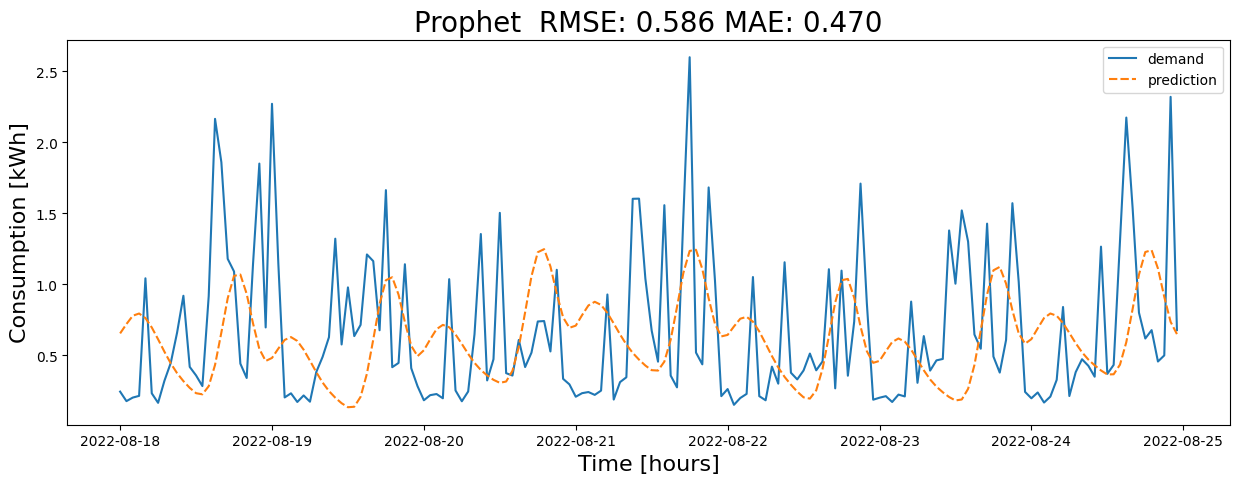

In [ ]:
  mapestring="MAPE: %.3f" % (overall_mape*100)
  maestring="MAE: %.3f" % (overall_mae)
  rmsestring = "RMSE: %.3f" % (overall_rmse)

  print(mapestring+" "+maestring+" "+rmsestring)

  plt.figure(figsize=(15,5))
  p = sns.lineplot(data = actual_full.join(forecast_full));
  plt.title("Prophet " +" "+rmsestring+" "+maestring,fontsize = 20)
  p.set_xlabel("Time [hours]", fontsize = 16);
  p.set_ylabel("Consumption [kWh]", fontsize = 16);